# 第 8 章 · MLP 前向与反向传播

> 配套 [ch8.html](../ch8.html) · 案例：血糖+运动 → 风险

## 1. 前向传播：计算图流水线

数据沿层流动；ReLU 截断负值；Sigmoid 输出概率。

,阶段,值
0,输入 x,[6.2 0.8]
1,z1=W1x+b1,[2.02 0.94]
2,h=ReLU(z1),[2.02 0.94]
3,ŷ=σ(W2h+b2),0.78 (网页 0.82)


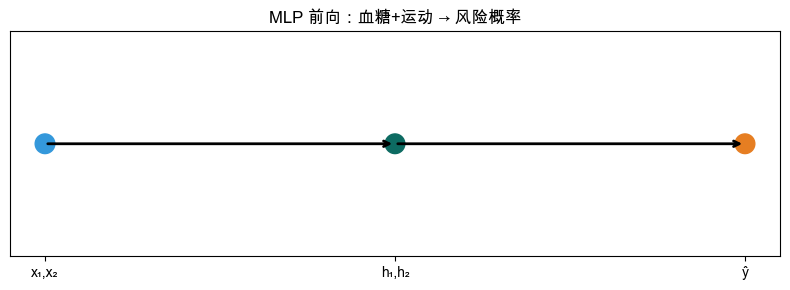

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "labs").exists() and (ROOT.parent / "labs").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "labs" / "ch08"))
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Heiti SC", "Arial Unicode MS", "DejaVu Sans"]
from IPython.display import display
from neural import *
display(forward_trace())
plot_mlp_flow()

**⚠️ 误区** · 前向不只推理时用——训练每个 batch 都要重算并**保存激活 a** 供反向用。

## 2. 反向传播：误差分责任

链式法则从 δ_out 回传到各层权重。

In [2]:
backward_demo()

δ_out=-0.027 (网页 0.036)
δ_h=[-0.013 -0.008] (网页 [0.018, 0.011])


**✅ 自测** · 若隐藏层 ReLU 输出全为 0，该层还能收到梯度吗？（ReLU′=0 则截断）